# Modélisation

On compare 3 modèles sur le dataset enrichi par nos nouvelles features :
- **Régression Logistique**
- **Random Forest**
- **LightGBM**

Le dataset est très déséquilibré (~6.7% de défauts). On utilise l'AUC-ROC comme métrique principale.


In [2]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, auc
)

df = pd.read_csv("../data/processed/cs-training-features.csv")
print(f"Taux de défaut : {df['SeriousDlqin2yrs'].mean() * 100:.2f} %")


Taux de défaut : 6.68 %


In [3]:
TARGET = "SeriousDlqin2yrs"

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train.shape[0]:,} lignes")
print(f"Test  : {X_test.shape[0]:,} lignes")


Train : 120,000 lignes
Test  : 30,000 lignes


## Modèle 1 : Régression Logistique (baseline)

Modèle linéaire simple. Il sert de référence.

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]
auc_lr = roc_auc_score(y_test, y_proba_lr)
print(f"AUC-ROC Régression Logistique : {auc_lr:.4f}")


AUC-ROC Régression Logistique : 0.8268


## Modèle 2 : Random Forest

Ensemble d'arbres de décision. On utilise `class_weight="balanced"` pour compenser le déséquilibre des classes.

In [5]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

y_proba_rf = rf.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, y_proba_rf)
print(f"AUC-ROC Random Forest : {auc_rf:.4f}")

AUC-ROC Random Forest : 0.8659


## Modèle 3 : LightGBM

Gradient boosting optimisé. Généralement le plus performant sur les données tabulaires. `is_unbalance=True` gère le déséquilibre automatiquement.


In [8]:
import lightgbm as lgb

lgbm = lgb.LGBMClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    is_unbalance=True,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)
lgbm.fit(X_train, y_train)

y_proba_lgbm = lgbm.predict_proba(X_test)[:, 1]
auc_lgbm = roc_auc_score(y_test, y_proba_lgbm)
print(f"AUC-ROC LightGBM : {auc_lgbm:.4f}")


AUC-ROC LightGBM : 0.8664


## Comparaison des courbes ROC

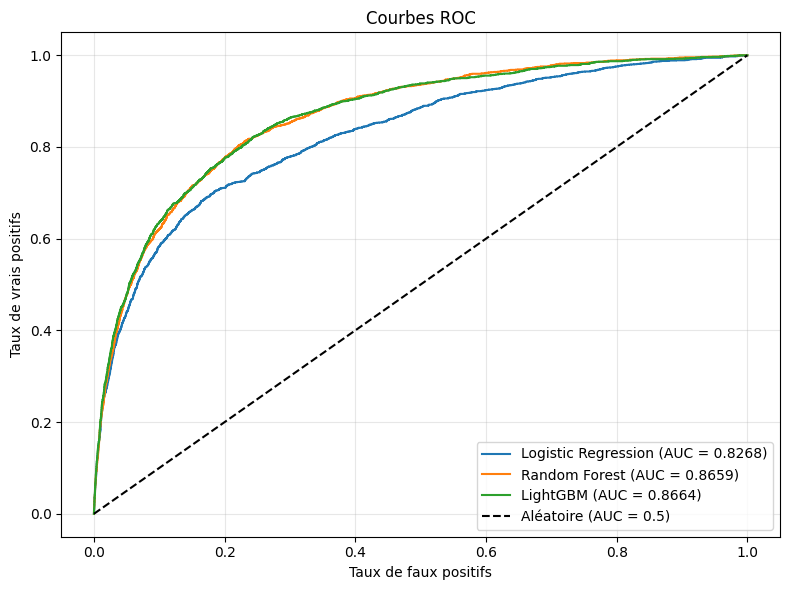

In [10]:
plt.figure(figsize=(8, 6))

for name, y_proba in [("Logistic Regression", y_proba_lr), ("Random Forest", y_proba_rf), ("LightGBM", y_proba_lgbm)]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.4f})")

plt.plot([0, 1], [0, 1], "k--", label="Aléatoire (AUC = 0.5)")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbes ROC")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Matrice de confusion

               precision    recall  f1-score   support

Pas de défaut       0.98      0.81      0.89     27995
       Défaut       0.23      0.76      0.35      2005

     accuracy                           0.81     30000
    macro avg       0.60      0.79      0.62     30000
 weighted avg       0.93      0.81      0.85     30000



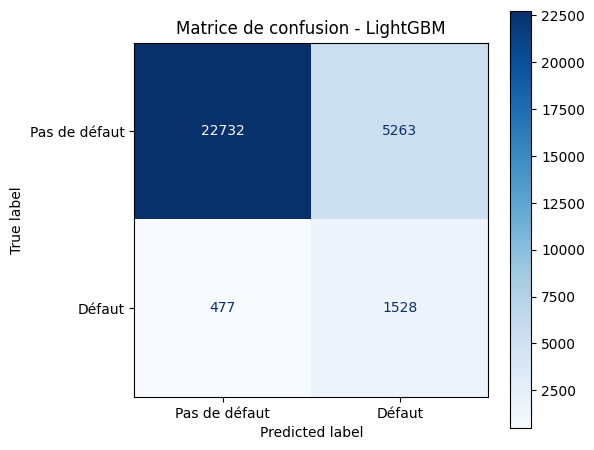

In [14]:
y_pred = (y_proba_lgbm >= 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=["Pas de défaut", "Défaut"]))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Pas de défaut", "Défaut"], ax=ax, cmap="Blues")
plt.title("Matrice de confusion - LightGBM")
plt.tight_layout()
plt.show()


## Conclusion

**LightGBM** est retenu comme meilleur modèle.

### Analyse du rapport de classification

- **Recall "Défaut" = 76%** : le modèle détecte correctement 3 mauvais payeurs sur 4. C'est le chiffre le plus important pour une banque, mieux vaut refuser un bon client que prêter à quelqu'un qui ne remboursera pas.
- **Precision "Défaut" = 23%** : quand le modèle signale un client comme risqué, il se trompe 77% du temps (fausses alertes).


## Optimisation des hyperparamètres

**Grid Search** teste toutes les combinaisons possibles sur une grille. Si on a 5 paramètres avec 4 valeurs chacun, ça fait 4⁵ = 1024 essais. La majorité sont inutiles (des zones que l'on sait déjà mauvaises).

**Optuna** fonctionne différemment. Il utilise un algorithme bayésien (Tree-structured Parzen Estimator) :

1. Il lance quelques essais aléatoires pour "explorer le terrain"
2. Il construit un modèle probabiliste de la relation entre les hyperparamètres et le score AUC
3. Il choisit le prochain essai en se concentrant sur les zones qui ont le plus de chances d'améliorer le score
4. À chaque essai, il affine sa compréhension et devient de plus en plus précis

Résultat : en **50 essais**, Optuna trouve souvent un résultat comparable à un grid search de 1000+ essais.

On évalue chaque combinaison avec une validation croisée stratifiée à 5 folds (on découpe le dataset d'entraînement en 5 morceaux, on entraîne sur 4, on teste sur le 5ème, et on recommence 5 fois). Cela évite de sur-optimiser sur un seul découpage chance.

In [16]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 127),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "is_unbalance": True,
        "random_state": 42,
        "n_jobs": -1,
        "verbose": -1,
    }

    model = lgb.LGBMClassifier(**params)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc")

    return scores.mean()

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print(f"Meilleur AUC-ROC (CV) : {study.best_value:.4f}")
print(f"Meilleurs paramètres  : {study.best_params}")

Meilleur AUC-ROC (CV) : 0.8657
Meilleurs paramètres  : {'n_estimators': 467, 'max_depth': 5, 'learning_rate': 0.015979916201671447, 'num_leaves': 77, 'min_child_samples': 100, 'reg_alpha': 4.435718419647249, 'reg_lambda': 0.6610535955913199, 'subsample': 0.8236130817018508, 'colsample_bytree': 0.5627027462431399}


## Réentraînement avec les meilleurs paramètres

In [18]:
best_params = study.best_params
best_params["is_unbalance"] = True
best_params["random_state"] = 42
best_params["n_jobs"] = -1
best_params["verbose"] = -1

lgbm_tuned = lgb.LGBMClassifier(**best_params)
lgbm_tuned.fit(X_train, y_train)

y_proba_tuned = lgbm_tuned.predict_proba(X_test)[:, 1]
auc_tuned = roc_auc_score(y_test, y_proba_tuned)

print(f"AUC-ROC avant optimisation : {auc_lgbm:.4f}")
print(f"AUC-ROC après optimisation : {auc_tuned:.4f}")


AUC-ROC avant optimisation : 0.8664
AUC-ROC après optimisation : 0.8704


## Courbe ROC

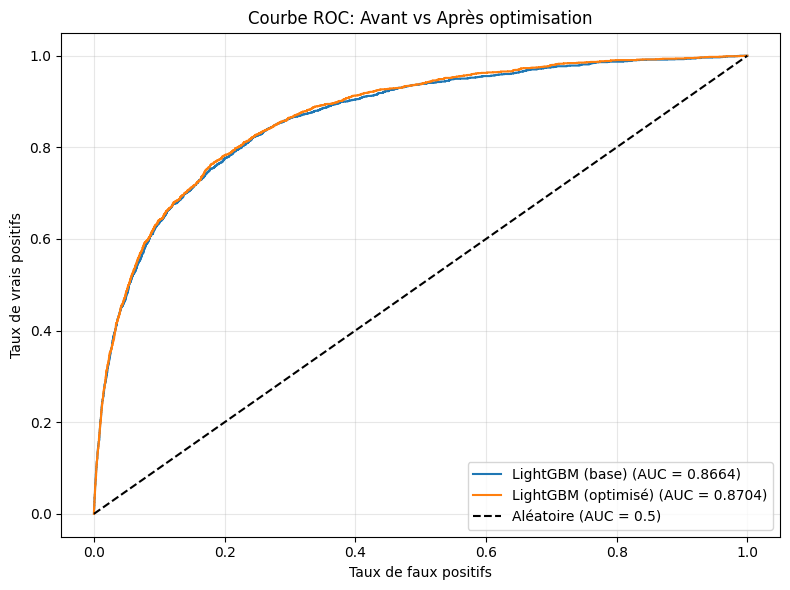

In [21]:
plt.figure(figsize=(8, 6))

for name, y_proba, auc_val in [
    ("LightGBM (base)", y_proba_lgbm, auc_lgbm),
    ("LightGBM (optimisé)", y_proba_tuned, auc_tuned),
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.4f})")

plt.plot([0, 1], [0, 1], "k--", label="Aléatoire (AUC = 0.5)")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbe ROC: Avant vs Après optimisation")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
